## Download and Importing Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import radians
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, confusion_matrix, PrecisionRecallDisplay, RocCurveDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from matplotlib.gridspec import GridSpec

In [3]:
df = pd.read_csv('/content/credit_card_transactions.csv')
print("CSV data loaded successfully. Displaying the first 5 rows:")
df.head()

CSV data loaded successfully. Displaying the first 5 rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0,28705.0
1,1,2019-01-01 00:00:44,6.304233e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0,NaN
2,2,2019-01-01 00:00:51,3.885949e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0,83236.0
3,3,2019-01-01 00:01:16,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0,NaN
4,4,2019-01-01 00:03:06,3.755342e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0,22844.0


In [4]:
print(f"Total number of rows in df_csv: {len(df)}")

Total number of rows in df_csv: 84888


## Exploration

In [5]:
print("DataFrame Info:")
df.info()
print("\nDataFrame Head:")
print(df.head())
print("\nDataFrame Description:")
print(df.describe())
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicated Rows:")
print(df.duplicated().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84888 entries, 0 to 84887
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             84888 non-null  int64  
 1   trans_date_trans_time  84888 non-null  object 
 2   cc_num                 84887 non-null  float64
 3   merchant               84887 non-null  object 
 4   category               84887 non-null  object 
 5   amt                    84887 non-null  float64
 6   first                  84887 non-null  object 
 7   last                   84887 non-null  object 
 8   gender                 84887 non-null  object 
 9   street                 84887 non-null  object 
 10  city                   84887 non-null  object 
 11  state                  84887 non-null  object 
 12  zip                    84887 non-null  float64
 13  lat                    84887 non-null  float64
 14  long                   84887 non-null 

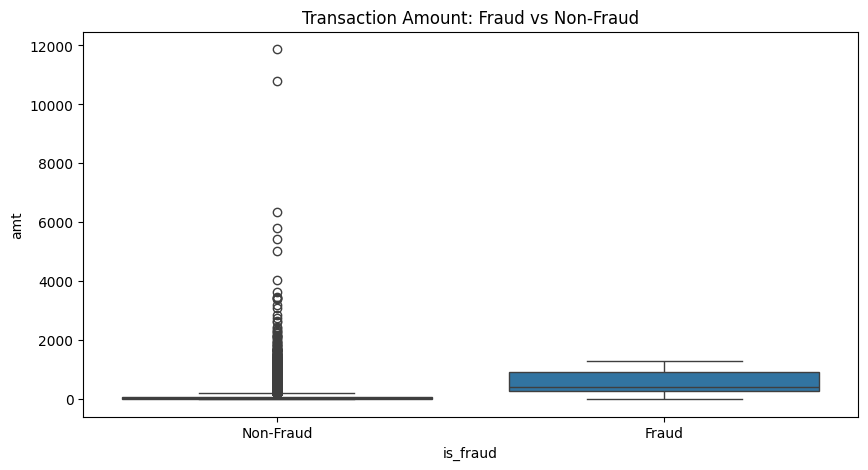

In [35]:
# Distribusi amount transaksi fraud vs non-fraud
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Transaction Amount: Fraud vs Non-Fraud')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

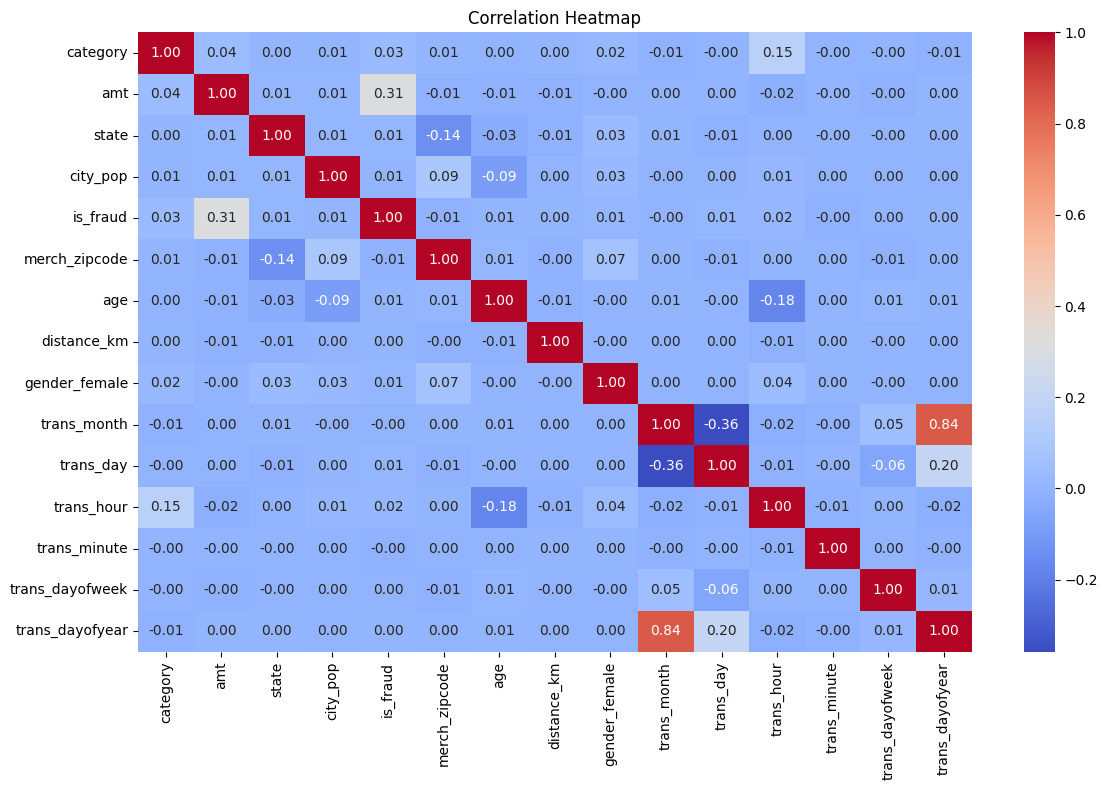

In [40]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

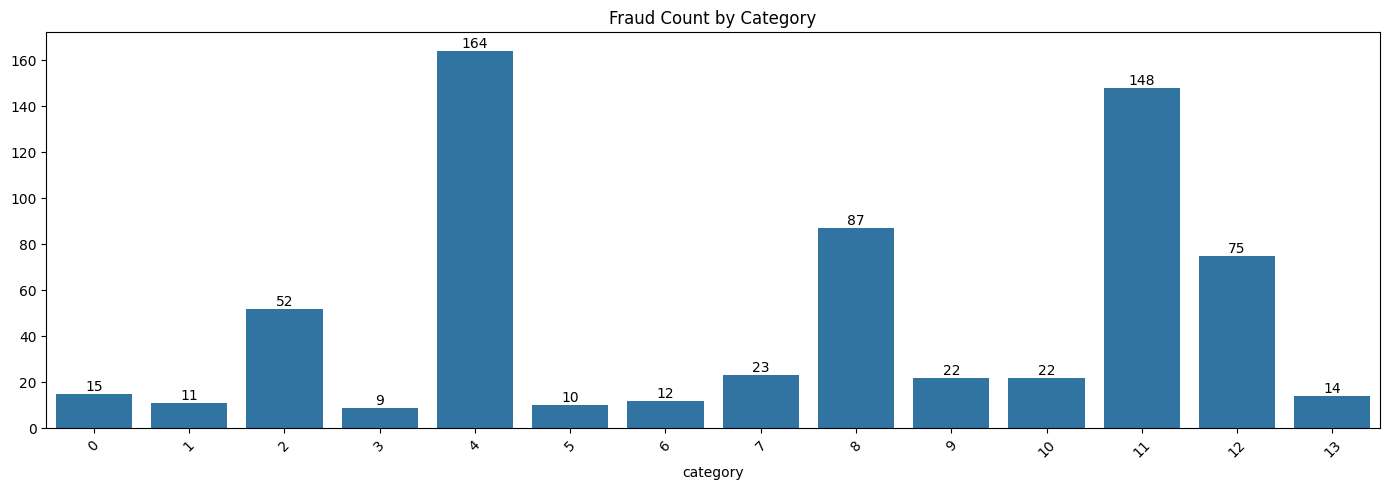

In [42]:
# Fraud by category
plt.figure(figsize=(14, 5))
fraud_by_cat = df[df['is_fraud']==1]['category'].value_counts()
ax = sns.barplot(x=fraud_by_cat.index, y=fraud_by_cat.values)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Fraud Count by Category')
plt.tight_layout()
plt.show()

## Preprocessing

Cleaning

In [6]:
# Dropping nulls
print(f"Number of rows before dropping nulls: {len(df)}")
print("Null values before dropping (columns with at least one null):\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

df.dropna(inplace=True)

print(f"\nNumber of rows after dropping nulls: {len(df)}")
print("Null values after dropping (columns with at least one null):\n")

print(df.isnull().sum()[df.isnull().sum() > 0])

df.reset_index(drop=True, inplace=True)
print("\nDataFrame index has been reset.")

Number of rows before dropping nulls: 84888
Null values before dropping (columns with at least one null):

cc_num               1
merchant             1
category             1
amt                  1
first                1
last                 1
gender               1
street               1
city                 1
state                1
zip                  1
lat                  1
long                 1
city_pop             1
job                  1
dob                  1
trans_num            1
unix_time            1
merch_lat            1
merch_long           1
is_fraud             1
merch_zipcode    12957
dtype: int64

Number of rows after dropping nulls: 71931
Null values after dropping (columns with at least one null):

Series([], dtype: int64)

DataFrame index has been reset.


In [7]:
#Dropping duplicate
print(f"Initial number of rows: {len(df)}")
print(f"Initial number of duplicated rows: {df.duplicated().sum()}")

df_cleaned = df.drop_duplicates()

print(f"Number of rows after dropping duplicates: {len(df_cleaned)}")
print(f"Number of duplicated rows after dropping duplicates: {df_cleaned.duplicated().sum()}")

df = df_cleaned.copy()
print("Duplicated rows have been dropped from the DataFrame.")

Initial number of rows: 71931
Initial number of duplicated rows: 0
Number of rows after dropping duplicates: 71931
Number of duplicated rows after dropping duplicates: 0
Duplicated rows have been dropped from the DataFrame.


In [8]:
# Dropping columns
df.drop(columns=['first', 'last', 'street', 'trans_num', 'unix_time', 'zip', 'Unnamed: 0', 'cc_num'], inplace=True)

# Transform dob jadi usia
df['age'] = (pd.to_datetime(df['trans_date_trans_time']) - pd.to_datetime(df['dob'])).dt.days // 365
df.drop(columns=['dob'], inplace=True)

In [9]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radius bumi dalam km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)

df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

In [10]:
# Label encoding 'gender_female'
df['gender_female'] = df['gender'].map({'M': 0, 'F': 1})

print("Original 'gender' column value counts:")
print(df['gender'].value_counts())
print("\nNew 'gender_female' column value counts:")
print(df['gender_female'].value_counts())

# Drop 'gender'
df.drop(columns=['gender'], inplace=True)


Original 'gender' column value counts:
gender
F    39157
M    32774
Name: count, dtype: int64

New 'gender_female' column value counts:
gender_female
1    39157
0    32774
Name: count, dtype: int64


In [11]:
if 'job' in df.columns:
    print(f"The 'job' column has {df['job'].nunique()} unique values.")
    print("Value counts for 'job':")
    print(df['job'].value_counts())

    if df['job'].nunique() > 100:
      df.drop(columns=['job'], inplace=True)
      print("The 'job' column has been deleted due to high cardinality.")

The 'job' column has 477 unique values.
Value counts for 'job':
job
Exhibition designer               600
Systems developer                 523
Designer, ceramics/pottery        512
Financial adviser                 465
Naval architect                   455
                                 ... 
Interpreter                         8
Armed forces technical officer      8
Merchandiser, retail                8
Contracting civil engineer          7
Hydrogeologist                      5
Name: count, Length: 477, dtype: int64
The 'job' column has been deleted due to high cardinality.


In [12]:
print(f"Initial DataFrame shape: {df.shape}")

# Process 'trans_date_trans_time' if it exists
if 'trans_date_trans_time' in df.columns:
    print("\nProcessing 'trans_date_trans_time'...")
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

    # Extract time-based numerical features
    df['trans_month'] = df['trans_date_trans_time'].dt.month
    df['trans_day'] = df['trans_date_trans_time'].dt.day
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df['trans_minute'] = df['trans_date_trans_time'].dt.minute
    df['trans_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek
    df['trans_dayofyear'] = df['trans_date_trans_time'].dt.dayofyear

    # Drop the original 'trans_date_trans_time' column
    df.drop(columns=['trans_date_trans_time'], inplace=True)
    print(f"DataFrame shape after processing 'trans_date_trans_time': {df.shape}")

# Identify remaining object columns
object_cols = df.select_dtypes(include=['object']).columns
print(f"\nRemaining object columns: {list(object_cols)}")

# General handling for other remaining object columns
le = LabelEncoder()
for col in object_cols:
    num_unique = df[col].nunique() # Corrected: use num_unique before conditional drop
    if num_unique < 100:
        print(f"Numerically encoding '{col}' (unique values: {num_unique})")
        df[col] = le.fit_transform(df[col])
        print(f"Value counts for '{col}':")
        print(df[col].value_counts())
    else:
        print(f"Dropping '{col}' due to high cardinality (unique values: {num_unique})")
        df.drop(columns=[col], inplace=True)

print(f"\nFinal DataFrame shape after encoding/dropping categorical features: {df.shape}")
print("DataFrame Info after processing:")
df.info()

Initial DataFrame shape: (71931, 12)

Processing 'trans_date_trans_time'...
DataFrame shape after processing 'trans_date_trans_time': (71931, 17)

Remaining object columns: ['merchant', 'category', 'city', 'state']
Dropping 'merchant' due to high cardinality (unique values: 693)
Numerically encoding 'category' (unique values: 14)
Value counts for 'category':
category
2     7437
4     6922
6     6798
12    6415
7     6054
11    5492
0     5219
1     5059
10    4996
5     4875
9     4395
8     3639
3     2419
13    2211
Name: count, dtype: int64
Dropping 'city' due to high cardinality (unique values: 842)
Numerically encoding 'state' (unique values: 49)
Value counts for 'state':
state
36    5122
41    4940
32    4689
33    2858
12    2858
22    2579
0     2548
3     2532
20    2238
1     1998
25    1900
43    1878
15    1819
21    1766
10    1738
47    1729
13    1697
38    1671
7     1666
46    1662
18    1600
34    1600
8     1519
29    1440
27    1418
14    1400
23    1275
40    1121


In [13]:
df.tail(5)

,category,amt,state,city_pop,is_fraud,merch_zipcode,age,distance_km,gender_female,trans_month,trans_day,trans_hour,trans_minute,trans_dayofweek,trans_dayofyear
71926,7,55.10,41,1595797.0,0.0,77994.0,23,97.888157,0,2,19,12,21,1,50
71927,10,69.80,27,566.0,0.0,57014.0,44,88.871863,0,2,19,12,21,1,50
71928,0,20.15,2,1312922.0,0.0,85326.0,19,61.915932,1,2,19,12,21,1,50
71929,7,116.38,32,10717.0,0.0,13160.0,66,54.566886,0,2,19,12,23,1,50
71930,1,81.13,35,260.0,0.0,97411.0,62,79.241455,1,2,19,12,23,1,50


Splitting

In [14]:
print("\nRe-splitting data after all preprocessing steps...")

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Split data (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of is_fraud in original dataset:")
print(y.value_counts(normalize=True))
print("\nDistribution of is_fraud in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of is_fraud in y_test:")
print(y_test.value_counts(normalize=True))


Re-splitting data after all preprocessing steps...
X_train shape: (50351, 14)
X_test shape: (21580, 14)
y_train shape: (50351,)
y_test shape: (21580,)

Distribution of is_fraud in original dataset:
is_fraud
0.0    0.990769
1.0    0.009231
Name: proportion, dtype: float64

Distribution of is_fraud in y_train:
is_fraud
0.0    0.990765
1.0    0.009235
Name: proportion, dtype: float64

Distribution of is_fraud in y_test:
is_fraud
0.0    0.990778
1.0    0.009222
Name: proportion, dtype: float64


Distribution of Transaction Classes:
is_fraud
0.0    71267
1.0      664
Name: count, dtype: int64

Total Non-Fraudulent Transactions (Class 0): 71267
Total Fraudulent Transactions (Class 1): 664


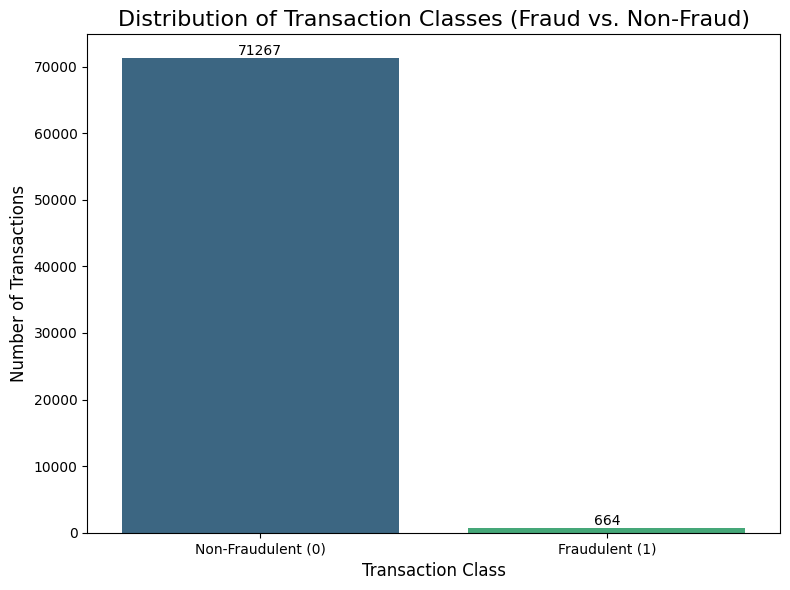

In [15]:
fraud_counts = df['is_fraud'].value_counts()
print("Distribution of Transaction Classes:")
print(fraud_counts)

print(f"\nTotal Non-Fraudulent Transactions (Class 0): {fraud_counts.get(0.0, 0)}")
print(f"Total Fraudulent Transactions (Class 1): {fraud_counts.get(1.0, 0)}")

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='is_fraud', data=df, palette='viridis', hue='is_fraud', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Transaction Classes (Fraud vs. Non-Fraud)', fontsize=16)
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'])

plt.tight_layout()
plt.show()

## SMOTE (Synthetic Minority Over-sampling Technique)

In [16]:
print("Original training set shape:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# Determine the minority class and its count
class_counts = y_train.value_counts()
minority_class_label = class_counts.idxmin()
minority_count = class_counts.min()

sm = SMOTE(random_state=42)

# SMOTE requires k_neighbors (default 5) to be less than the number of samples in the minority class.
# This means it needs at least k_neighbors + 1 samples in the minority class.
if minority_count <= sm.k_neighbors:
    print(f"\nWarning: SMOTE cannot be applied. The minority class (Class {int(minority_class_label)}) has only {minority_count} sample(s).")
    print(f"SMOTE requires k_neighbors (default {sm.k_neighbors}) to be less than the number of samples in the minority class (i.e., at least {sm.k_neighbors + 1} samples).")
    print("Proceeding without SMOTE resampling. X_train_res and y_train_res will be set to X_train and y_train.")
    X_train_res, y_train_res = X_train, y_train # Fallback to original data
else:
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print("\nResampled training set shape (SMOTE):")
    print(f"X_train_res: {X_train_res.shape}, y_train_res: {y_train_res.shape}")

print("\nDistribution of is_fraud in original y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of is_fraud in resampled y_train_res:")
print(y_train_res.value_counts(normalize=True))

Original training set shape:
X_train: (50351, 14), y_train: (50351,)

Resampled training set shape (SMOTE):
X_train_res: (99772, 14), y_train_res: (99772,)

Distribution of is_fraud in original y_train:
is_fraud
0.0    0.990765
1.0    0.009235
Name: proportion, dtype: float64

Distribution of is_fraud in resampled y_train_res:
is_fraud
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


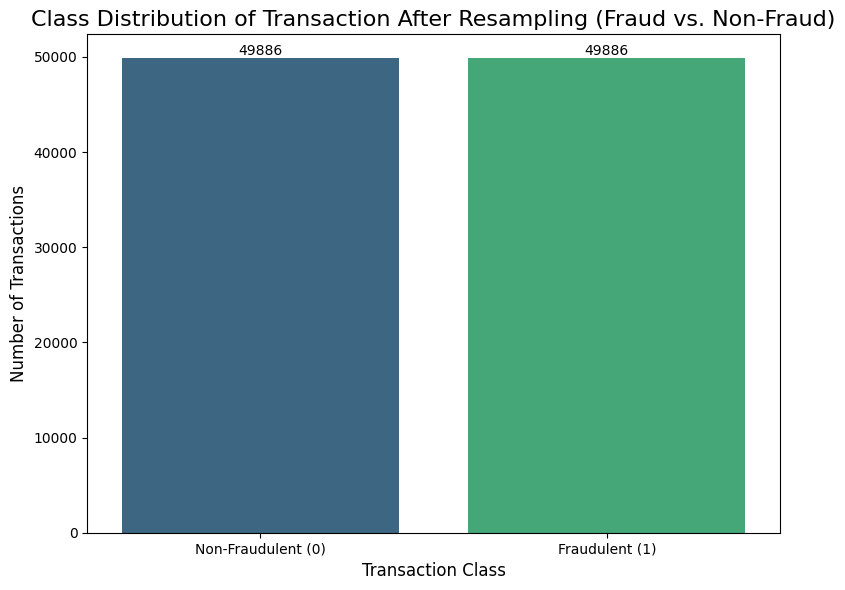

In [17]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Class', data=pd.DataFrame({'Class': y_train_res}), palette='viridis', hue='Class', legend=False)

# Add number counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Class Distribution of Transaction After Resampling (Fraud vs. Non-Fraud)', fontsize=16)
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'])

plt.tight_layout()
plt.show()

## Model Creation

Logistic Regression

In [18]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train_res_scaled, y_train_res)

prediction_lr = logistic_regression.predict(X_test_scaled)
logistic_regression_score = logistic_regression.score(X_test_scaled, y_test)

#accuracy train prediction
X_train_prediction = logistic_regression.predict(X_train_res_scaled)
training_accuracy_lr = accuracy_score(y_train_res, X_train_prediction)

#accuracy test prediction
X_test_prediction = logistic_regression.predict(X_test_scaled)
test_accuracy_lr = accuracy_score(y_test, X_test_prediction)

print("Logistic Regression Score: ", logistic_regression_score)
print("Accuracy on Training data: ", training_accuracy_lr)
print("Accuracy on Test data: ", test_accuracy_lr)

Logistic Regression Score:  0.9496292863762743
Accuracy on Training data:  0.9016156837589705
Accuracy on Test data:  0.9496292863762743


Random Forest

In [19]:
random_forest = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
random_forest.fit(X_train_res, y_train_res)

prediction_rf = random_forest.predict(X_test)
random_forest_score = random_forest.score(X_test, y_test)

#accuracy train prediction
x_train_prediction = random_forest.predict(X_train_res)
training_accuracy_rf = accuracy_score(y_train_res, x_train_prediction)

#accuracy test prediction
x_test_prediction = random_forest.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, x_test_prediction)

print("Random Forest Score: ", random_forest_score)
print("Accuracy on Training data: ", training_accuracy_rf)
print("Accuracy on Test data: ", test_accuracy_rf)

Random Forest Score:  0.9933271547729379
Accuracy on Training data:  1.0
Accuracy on Test data:  0.9933271547729379


##Evaluation


Logistic Regression

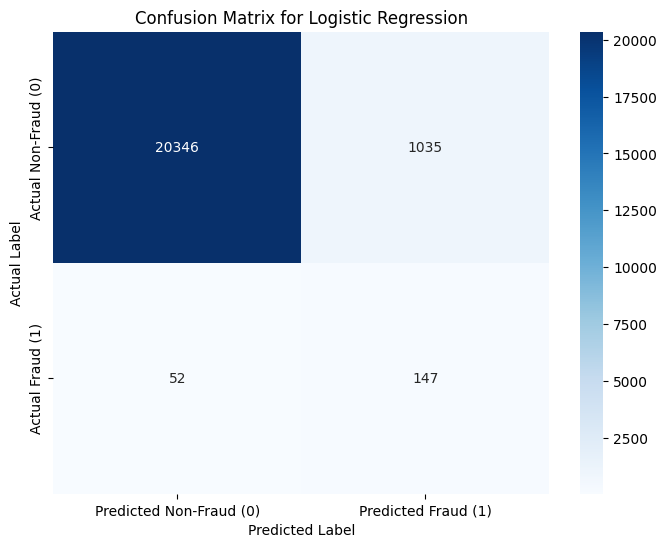

In [20]:
#Confusion Matrix
cm_lr = confusion_matrix(y_test, prediction_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [31]:
print(classification_report(y_test, prediction_lr))

print(f"\nLogistic Regression Score (Accuracy on Test data): {logistic_regression_score:.4f}")
print(f"Accuracy on Training data: {training_accuracy_lr:.4f}")
print(f"Accuracy on Test data (from accuracy_score): {test_accuracy_lr:.4f}")

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     21381
         1.0       0.12      0.74      0.21       199

    accuracy                           0.95     21580
   macro avg       0.56      0.85      0.59     21580
weighted avg       0.99      0.95      0.97     21580


Logistic Regression Score (Accuracy on Test data): 0.9496
Accuracy on Training data: 0.9016
Accuracy on Test data (from accuracy_score): 0.9496


<Figure size 1000x600 with 0 Axes>

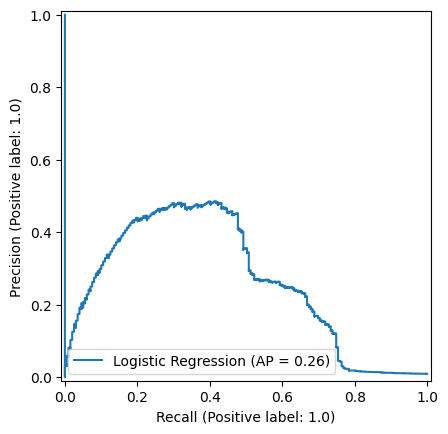

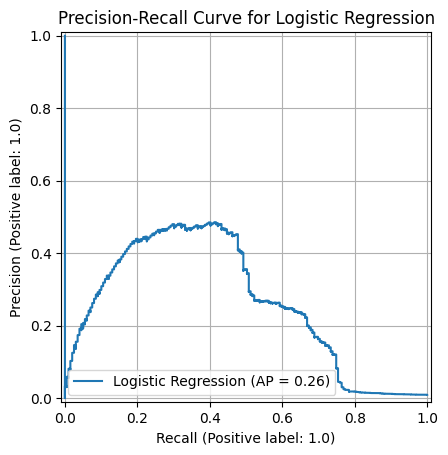

<Figure size 1000x600 with 0 Axes>

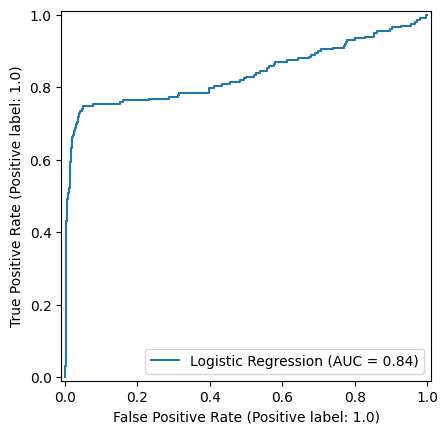

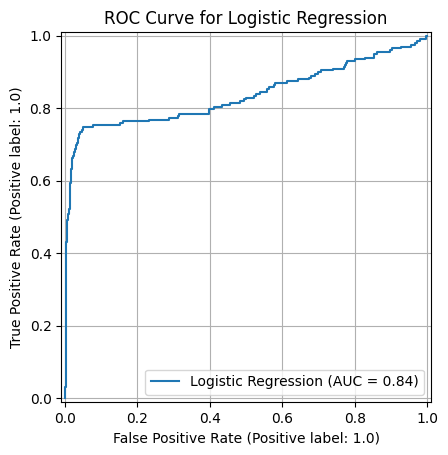

In [22]:
# PR Curve Logistic Regression
plt.figure(figsize=(10, 6))
pr_display = PrecisionRecallDisplay.from_estimator(logistic_regression, X_test_scaled, y_test, name='Logistic Regression')
pr_display.plot()
plt.title('Precision-Recall Curve for Logistic Regression')
plt.grid(True)
plt.show()

# ROC Curve Logistic Regression
plt.figure(figsize=(10, 6))
roc_display = RocCurveDisplay.from_estimator(logistic_regression, X_test_scaled, y_test, name='Logistic Regression')
roc_display.plot()
plt.title('ROC Curve for Logistic Regression')
plt.grid(True)
plt.show()

Random Forest

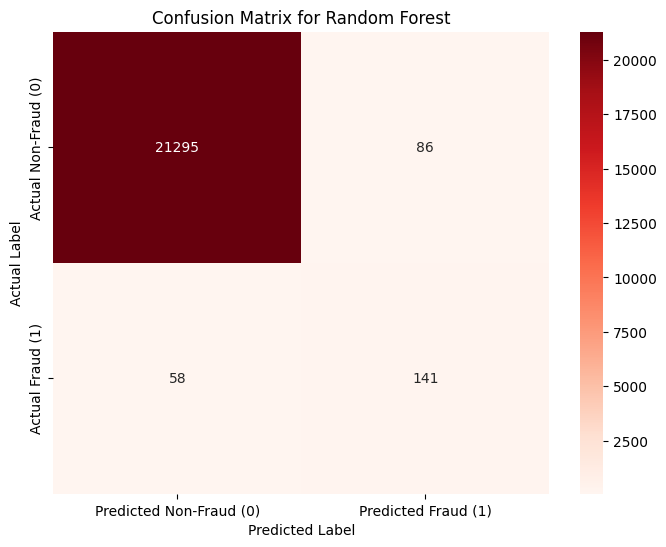

In [23]:
#Confusion Matrix
cm_rf = confusion_matrix(y_test, prediction_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [32]:
print(classification_report(y_test, prediction_rf))

print(f"\nRandom Forest Score (Accuracy on Test data): {random_forest_score:.4f}")
print(f"Accuracy on Training data: {training_accuracy_rf:.4f}")
print(f"Accuracy on Test data (from accuracy_score): {test_accuracy_rf:.4f}")

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     21381
         1.0       0.62      0.71      0.66       199

    accuracy                           0.99     21580
   macro avg       0.81      0.85      0.83     21580
weighted avg       0.99      0.99      0.99     21580


Random Forest Score (Accuracy on Test data): 0.9933
Accuracy on Training data: 1.0000
Accuracy on Test data (from accuracy_score): 0.9933


<Figure size 1000x600 with 0 Axes>

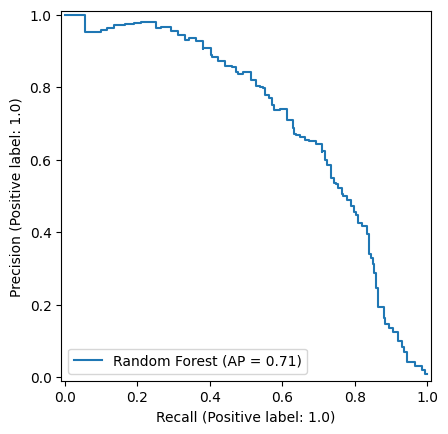

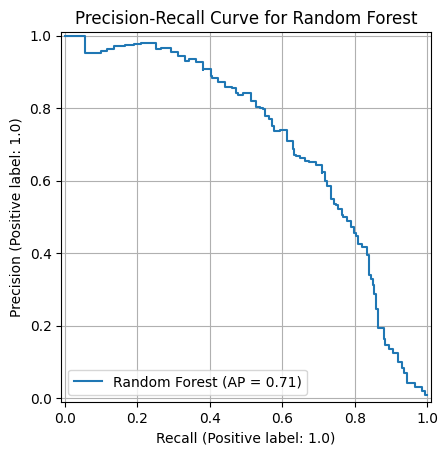

<Figure size 1000x600 with 0 Axes>

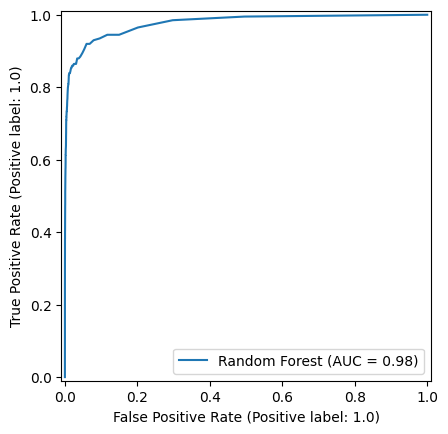

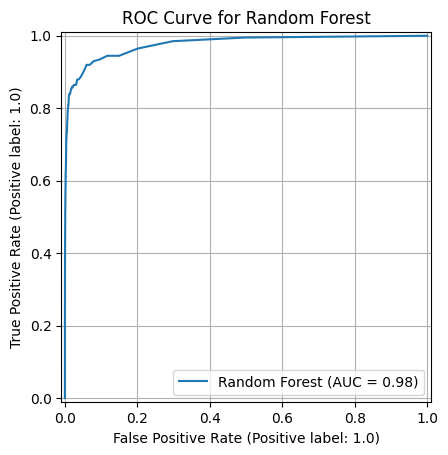

In [25]:
# PR Curve Random Forest
plt.figure(figsize=(10, 6))
pr_display_rf = PrecisionRecallDisplay.from_estimator(random_forest, X_test, y_test, name='Random Forest')
pr_display_rf.plot()
plt.title('Precision-Recall Curve for Random Forest')
plt.grid(True)
plt.show()

# ROC Curve Random Forest
plt.figure(figsize=(10, 6))
roc_display_rf = RocCurveDisplay.from_estimator(random_forest, X_test, y_test, name='Random Forest')
roc_display_rf.plot()
plt.title('ROC Curve for Random Forest')
plt.grid(True)
plt.show()

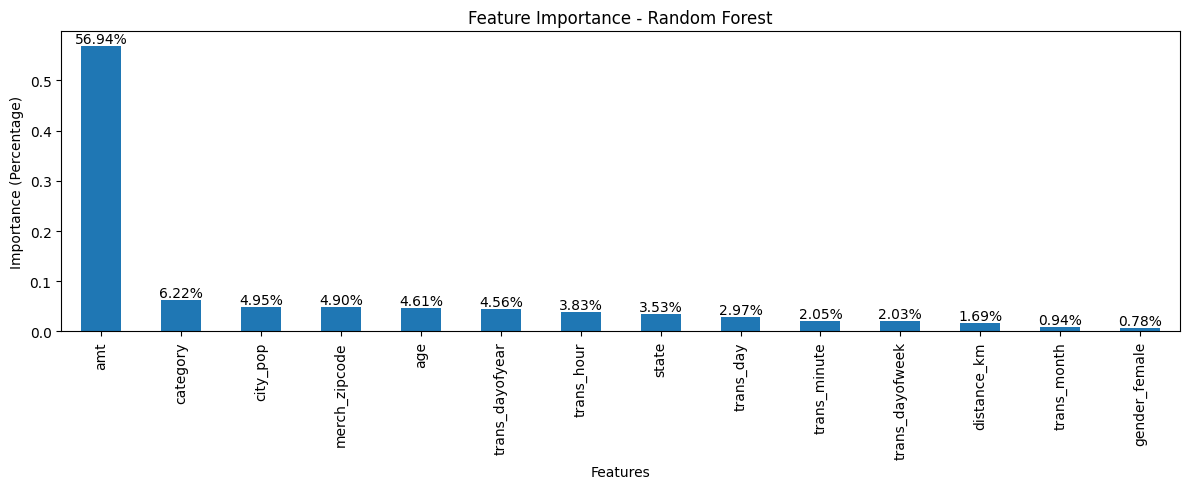

In [30]:
# Feature importance
importances = pd.Series(random_forest.feature_importances_, index=X.columns)
ax = importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))

# Add number labels for each bar, formatted as percentage
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance (Percentage)')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

Comparison

In [33]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [training_accuracy_lr, training_accuracy_rf],
    'Test Accuracy': [test_accuracy_lr, test_accuracy_rf],
})
print(comparison.to_string(index=False))

              Model  Train Accuracy  Test Accuracy
Logistic Regression        0.901616       0.949629
      Random Forest        1.000000       0.993327


## Deploy

In [44]:
import joblib

# Save the trained Random Forest model
joblib.dump(random_forest, 'model_fraud_rf.pkl') #dijalankan sistem

# Save the Scaler
joblib.dump(scaler, 'scaler_fraud.pkl')

print("Random Forest Model and Scaler successfully exported!")

Random Forest Model and Scaler successfully exported!
